# Part 1: Backpropagation

In [68]:
# Thinking process: Backpropagation is applying the chain rule in calculus to find the gradient of a function wrt to its input
# So the first step is to connect inputs to function in a child-parent relationship

import math


class Weight:

    def __init__(self, data, label = 'ukn', _children = [], _op = None, _is_leaf = True) -> None:
        self.label = label
        self.data = data
        self.grad = 0.0
        self._children = _children
        self._op = _op
        self._backward = lambda : None
        self._is_leaf = _is_leaf

    def backward(self):
        """Backprop uses reverse topological order"""
        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.children():
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()
    
    def __repr__(self) -> str:
        return self.label + "|" + str(self.data) + "|" + str(self.grad)
    
    def __add__(self, other):
        other = other if isinstance(other, Weight) else Weight(other)
        out = Weight(self.data + other.data, _children=[self, other], _op="+", _is_leaf=False)

        def backward():
            self.grad += 1 * out.grad
            other.grad += 1 * out.grad

        out._backward = backward

        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Weight) else Weight(other)
        out = Weight(self.data * other.data, _children=[self, other], _op="*", _is_leaf=False)

        def backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = backward

        return out
    
    def __sub__(self, other):
        return self + other * (-1)
    
    def __truediv__(self, other):
        return self * other**(-1)
    
    def __pow__(self, other):
        other = other if isinstance(other, Weight) else Weight(other)
        out = Weight(self.data ** other.data, _children=[self, other], _op="pow", _is_leaf=False)

        def backward():
            self.grad += other.data * self.data**(other.data - 1) * out.grad

        out._backward = backward

        return out
    
    def ReLU(self):
        out = Weight(max(0, self.data), _children=[self], _op="ReLU", _is_leaf=False)

        def backward():
            grad = 1 if self.data > 0 else 0  # if x = 0 choose subgradient 0
            self.grad += grad * out.grad

        out._backward = backward

        return out

    def sigmoid(self):
        e = math.exp(self.data)
        out = Weight(e / (1 + e), _children=[self], _op="Sigmoid", _is_leaf=False)

        def backward():
            grad = (e / (1 + e)) * (1 - e / (1 + e))
            self.grad += grad * out.grad

        out._backward = backward

        return out

    def log(self):
        out = Weight(math.log(self.data), _children=[self], _op="ln", _is_leaf=False)

        def backward():
            self.grad += 1 / self.data * out.grad

        out._backward = backward

        return out
    
    def __neg__(self): # -self
        return self * -1
    
    def __radd__(self, other): # other + self
        return self + other
    
    def __rsub__(self, other): # other - self
        return other + (-self)
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __rtruediv__(self, other): # other / self
        return other * self**-1
    
    def children(self):
        return self._children
    

In [6]:
a = Weight(2)
b = Weight(3)
c = a + b
c

weight: 5

In [27]:
# Add a relationship when an operation is carried out
a = Weight(2, 'a')
b = Weight(3, 'b')
c = a + b; c.label = 'c'
print(c)
print(c.children())

c|5|0.0
[a|2|0.0, b|3|0.0]


In [2]:
# Let's visualize the connection (code from Karpathy's lecture)
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = list(), list()

    def build(v):
        if v not in nodes:
            nodes.append(v)
            for child in v.children():
                edges.append((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
            shape='record',
        )
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [ ]:
# Test _backward with a simple addition
a = Weight(2, 'a')
b = Weight(3, 'b')
c = a + b; c.label = 'c'
print(c)
print(c.children())

c|5|0.0
[a|2|0.0, b|3|0.0]


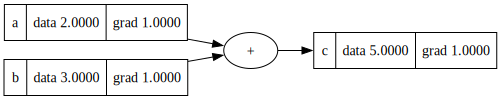

In [62]:
draw_dot(c)

In [ ]:
c._backward()

In [118]:
# A slightly more complex test
a = Weight(2, 'a')
b = Weight(3, 'b')
c = a + b; c.label = 'c'
d = Weight(-4, 'd')
e = c + d; e.label = 'e'
print(e)
print(e.children())

e|1|0.0
[c|5|0.0, d|-4|0.0]


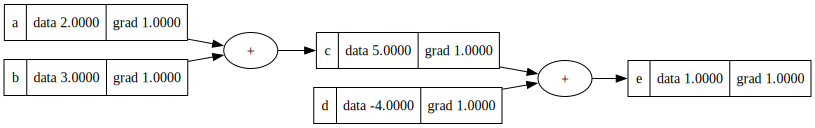

In [121]:
draw_dot(e)

In [ ]:
e.backward()

In [ ]:
# Special case test
a = Weight(2, 'a')
b = Weight(3, 'b')
c = a + a; c.label = 'c'
print(c)
print(c.children())

c|4|0.0
[a|2|0.0, a|2|0.0]


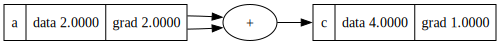

In [6]:
draw_dot(c)

In [ ]:
c.backward()

In [73]:
# Compare with PyTorch
a = Weight(0.212, 'a')
b = Weight(0.334, 'b')
c = a * b; c.label = 'c'
d = a + b; d.label = 'd'
e = c * d; e.label = 'e'
f = e.sigmoid(); f.label = 'f'
f

f|0.5096640882986002|0.0

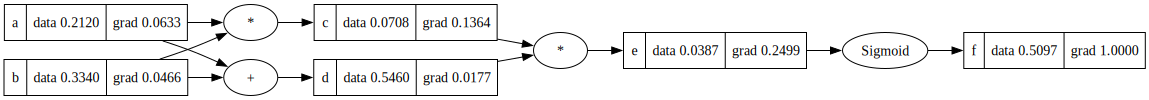

In [76]:
draw_dot(f)

In [75]:
f.backward()

In [77]:
import torch

a_t = torch.Tensor([0.212]); a_t.requires_grad = True
b_t = torch.Tensor([0.334]); b_t.requires_grad = True
c_t = a_t * b_t
d_t = a_t + b_t
e_t = c_t * d_t
f_t = torch.sigmoid(e_t)
f_t

tensor([0.5097], grad_fn=<SigmoidBackward0>)

In [78]:
f_t.backward()
a_t.grad, b_t.grad

(tensor([0.0633]), tensor([0.0466]))

# Part 2: Neural network

In [3]:
# Building a neural network

import random

class Neuron:
    """A neuron will have multiple inputs and a single output (activation)"""

    def __init__(self, in_features, activation_fn = 'linear') -> None:
        """activation function expects 'linear', 'relu' or 'sigmoid'"""
        self.in_features = in_features
        self.activation_fn = activation_fn
        self.w = [Weight(random.random(), 'w') for _ in range(self.in_features)]
        self.b = Weight(random.random(), 'b')

    def __call__(self, x):
        assert len(x) == len(self.w), "Dimension mismatch"
        activation = sum([self.w[i] * x[i] for i in range(self.in_features)]) + self.b
        if self.activation_fn == 'linear':
            return activation
        elif self.activation_fn == 'relu':
            return activation.ReLU()
        elif self.activation_fn == 'sigmoid':
            return activation.sigmoid()
    
    def parameters(self):
        return self.w + [self.b]


class Layer:
    """A layer of n Neurons"""

    def __init__(self, in_features, out_features, activation_fn = 'linear') -> None:
        self.in_features = in_features
        self.out_features = out_features
        self.activation_fn = activation_fn
        self.neurons = [Neuron(self.in_features, self.activation_fn) for _ in range(self.out_features)]

    def __call__(self, x):
        return [neuron(x) for neuron in self.neurons]
    
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

class NeuralNet:
    """A Linear neural network of n Layers"""

    def __init__(self, in_features, out_features : list, activation_fn : list) -> None:
        self.in_features = in_features
        self.out_features = out_features
        self.activation_fn = activation_fn
        self.input_dim = [self.in_features] + self.out_features[:-1]
        self.output_dim = self.out_features
        self.layers = [Layer(self.input_dim[i], self.output_dim[i], self.activation_fn[i]) for i in range(len(self.input_dim))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for n in self.layers for p in n.parameters()]

In [26]:
# Toy example for testing Neuron
random.seed(1)
x = [1.0, 1.0]
neuron = Neuron(2, 'sigmoid')
activation = neuron(x)
print(activation)
neuron.parameters()

ukn|0.8513935068399255|0.0


[w|0.13436424411240122|0.0, w|0.8474337369372327|0.0, b|0.763774618976614|0.0]

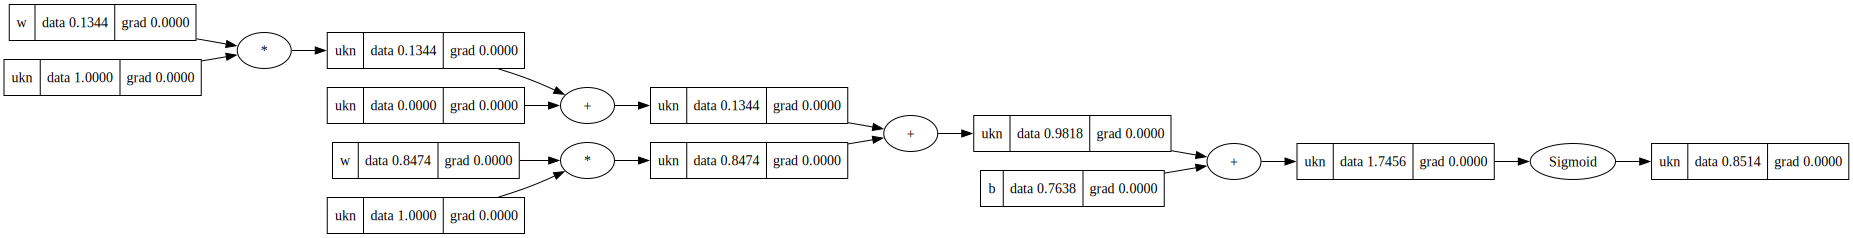

In [27]:
draw_dot(activation)

In [36]:
# Toy example for testing Layer
random.seed(1)
x = [1.0, 1.0]
layer = Layer(2, 3, 'sigmoid')
activations = layer(x)
print(activations)
print(len(layer.parameters()), 'params')
layer.parameters()

[ukn|0.8513935068399255|0.0, ukn|0.768523925623332|0.0, ukn|0.8226164784170326|0.0]
9 params


[w|0.13436424411240122|0.0,
 w|0.8474337369372327|0.0,
 b|0.763774618976614|0.0,
 w|0.2550690257394217|0.0,
 w|0.49543508709194095|0.0,
 b|0.4494910647887381|0.0,
 w|0.651592972722763|0.0,
 w|0.7887233511355132|0.0,
 b|0.0938595867742349|0.0]

In [47]:
# Toy example for testing NeuralNet
random.seed(1)
x = [1.0, 1.0]
model = NeuralNet(2, [1, 1, 1], ['relu', 'relu', 'sigmoid'])
out = model(x)
print(out)
print(len(model.parameters()), 'params')
model.parameters()

[ukn|0.7454363207596558|0.0]
7 params


[w|0.13436424411240122|0.0,
 w|0.8474337369372327|0.0,
 b|0.763774618976614|0.0,
 w|0.2550690257394217|0.0,
 b|0.49543508709194095|0.0,
 w|0.4494910647887381|0.0,
 b|0.651592972722763|0.0]

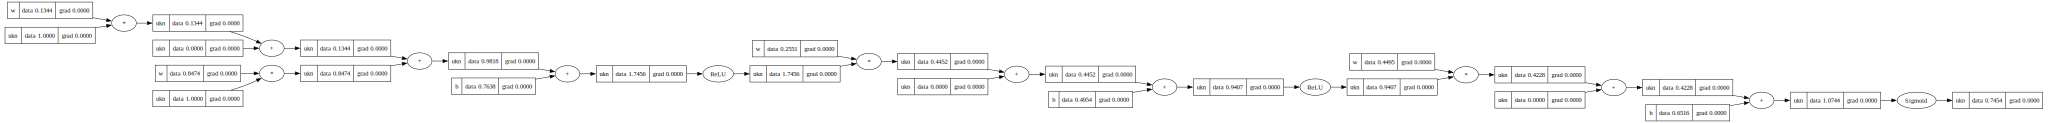

In [45]:
draw_dot(*out)

# Part 3: Training

In [102]:
# Dataset
X = [
    [1.0, 1.0],
    [1.0, 2.0],
    [2.0, 1.0],
    [2.0, 2.0]
]

y = [1.0, 1.0, 0.0, 0.0]

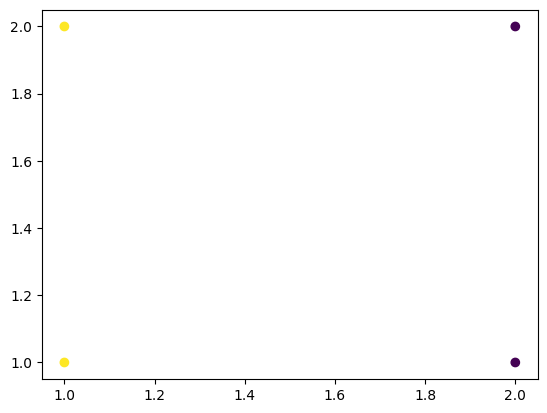

In [103]:
# Plot

import matplotlib.pyplot as plt

plt.figure()
x_coords = [x[0] for x in X]
y_coords = [x[1] for x in X]
plt.scatter(x_coords, y_coords, c=y)
plt.show()

In [104]:
# Model
random.seed(1)
mlp = NeuralNet(2, [4, 1], ['relu', 'sigmoid'])
print(len(mlp.parameters()), 'params')
mlp.parameters()

17 params


[w|0.13436424411240122|0.0,
 w|0.8474337369372327|0.0,
 b|0.763774618976614|0.0,
 w|0.2550690257394217|0.0,
 w|0.49543508709194095|0.0,
 b|0.4494910647887381|0.0,
 w|0.651592972722763|0.0,
 w|0.7887233511355132|0.0,
 b|0.0938595867742349|0.0,
 w|0.02834747652200631|0.0,
 w|0.8357651039198697|0.0,
 b|0.43276706790505337|0.0,
 w|0.762280082457942|0.0,
 w|0.0021060533511106927|0.0,
 w|0.4453871940548014|0.0,
 w|0.7215400323407826|0.0,
 b|0.22876222127045265|0.0]

In [105]:
y_pred = [mlp(x) for x in X]
y_pred

[[ukn|0.9601113554769547|0.0],
 [ukn|0.9916929429046133|0.0],
 [ukn|0.9732624014641723|0.0],
 [ukn|0.9944914687937499|0.0]]

In [83]:
# MSE loss
def MSE(y_pred : list, y_true : list):
    temp = list(zip([i[0] for i in y_pred], y_true))
    loss = sum([(y_hat - y)**2 for (y_hat, y) in temp]) / len(y_true)
    return loss

In [84]:
# BCE loss (in case you want to try)
def BCE(y_pred : list, y_true : list, _eps = 1e-7):
    temp = list(zip([i[0] for i in y_pred], y_true))
    loss = 0.0
    for (y_hat, y) in temp:
        # Clamping
        if y_hat == 0.0:
            y_hat += _eps
        elif y_hat == 1.0:
            y_hat -= _eps
        # Calculate loss
        loss += y * y_hat.log() + (1-y) * (1-y_hat).log()
    loss *= -1 / len(y_true)
    return loss

In [106]:
loss = MSE(y_pred, y); loss.label = 'loss'
loss

loss|0.48447827369170743|0.0

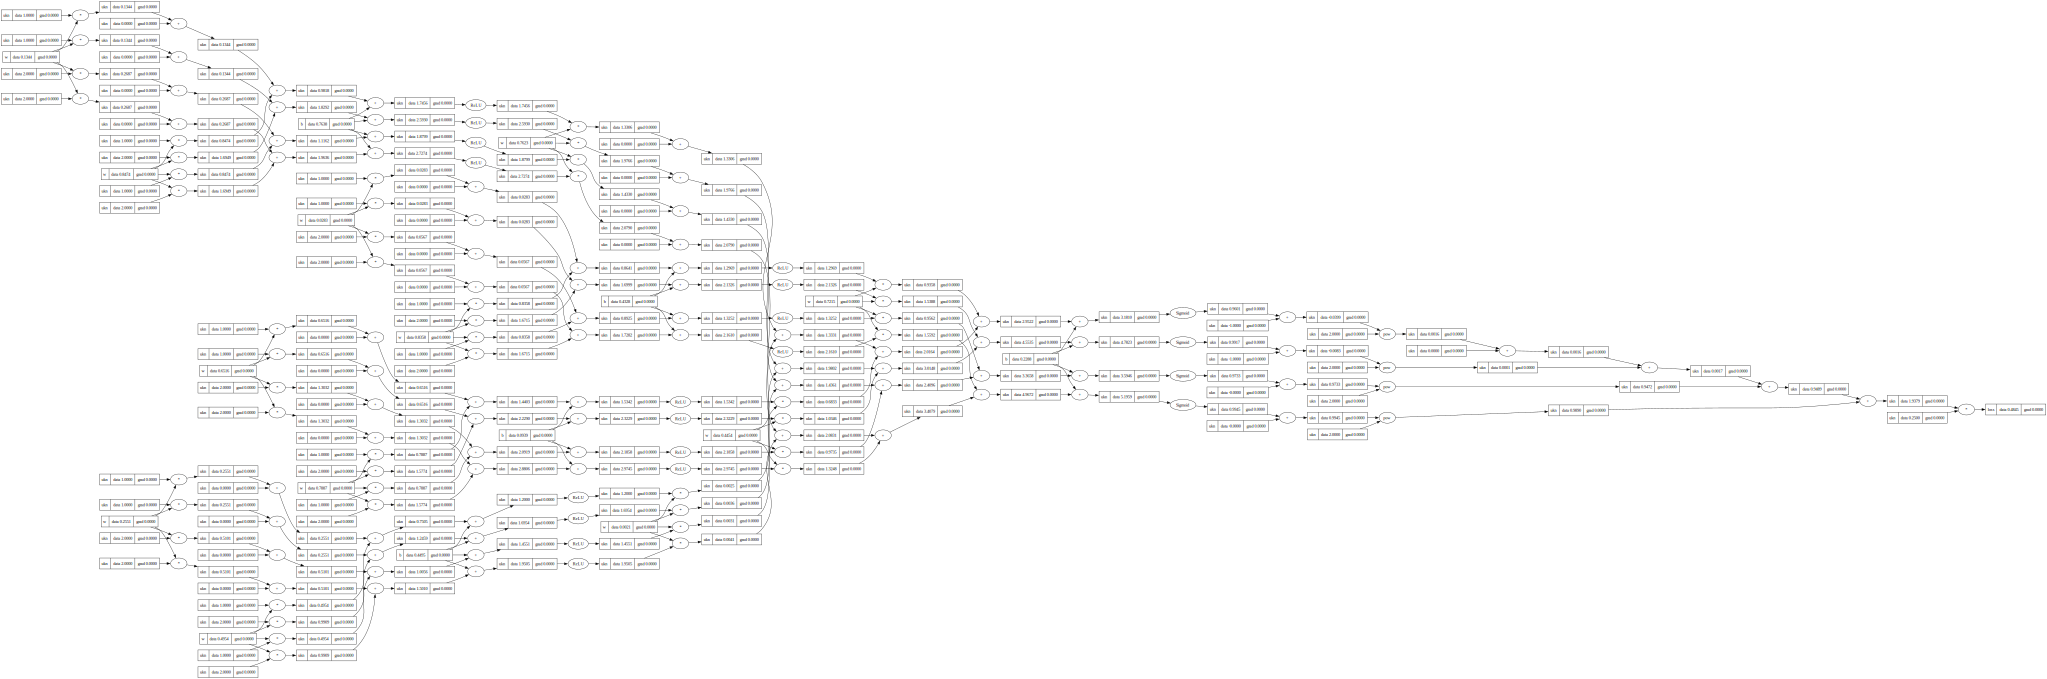

In [107]:
draw_dot(loss)

In [87]:
# Function for zeroing gradients
def zero_grad(loss):
    nodes, _ = trace(loss)
    for node in nodes:
        node.grad = 0.0

In [108]:
zero_grad(loss)
loss.backward()

In [109]:
mlp.layers[0].neurons[0].w[0].data, mlp.layers[0].neurons[0].w[0].grad

(0.13436424411240122, 0.02285078612798053)

In [110]:
# If we step any w opposite to the gradient, the loss should decrease

for p in mlp.parameters():
    p.data = p.data - 0.001 * p.grad  # gradient descent

In [111]:
mlp.layers[0].neurons[0].w[0].data, mlp.layers[0].neurons[0].w[0].grad

(0.13434139332627323, 0.02285078612798053)

In [112]:
# New prediction and new loss
y_pred_new = [mlp(x) for x in X]
loss_new = MSE(y_pred_new, y)
loss, loss_new  # old vs new

(loss|0.48447827369170743|1.0, ukn|0.4844731607194409|0.0)

In [ ]:
# Now less train for longer
def train(model, X, y, loss_function, epochs, learning_rate):
    for i in range(epochs):
        # forward pass
        y_pred = [model(x) for x in X]
        # Calculate loss
        loss = loss_function(y_pred, y)
        # backprop
        zero_grad(loss)
        loss.backward()
        # gradient descent
        for p in model.parameters():
            p.data = p.data - learning_rate * p.grad
        # log
        if i % 100 == 0:
            print(f"step {i}: loss {loss.data}")

In [114]:
train(mlp, X, y, MSE, 12000, 0.01)

step 0: loss 0.4844731607194409
step 100: loss 0.4773260284207308
step 200: loss 0.46164926976897225
step 300: loss 0.4145573354325499
step 400: loss 0.2630628177102026
step 500: loss 0.20033067893409445
step 600: loss 0.18986376330493004
step 700: loss 0.18007923742491974
step 800: loss 0.17001611805000863
step 900: loss 0.15985485766430163
step 1000: loss 0.14979721675591137
step 1100: loss 0.14002610382907338
step 1200: loss 0.130808118327443
step 1300: loss 0.12234513259273791
step 1400: loss 0.11436760621746664
step 1500: loss 0.1068947257268939
step 1600: loss 0.09993144064359478
step 1700: loss 0.09345651376324327
step 1800: loss 0.08744779371220333
step 1900: loss 0.08187506837681778
step 2000: loss 0.07670437397142464
step 2100: loss 0.07190532853587159
step 2200: loss 0.06745026605593284
step 2300: loss 0.06331209479384098
step 2400: loss 0.059466830909340185
step 2500: loss 0.05589168117190749
step 2600: loss 0.052566759458807344
step 2700: loss 0.049473972725342194
step 280

In [115]:
# New prediction
y_pred_new = [mlp(x) for x in X]
y_pred, y_pred_new  # old vs new

([[ukn|0.9601113554769547|-0.01994432226152265],
  [ukn|0.9916929429046133|-0.0041535285476933526],
  [ukn|0.9732624014641723|0.48663120073208616],
  [ukn|0.9944914687937499|0.49724573439687497]],
 [[ukn|0.9179102050494714|0.0],
  [ukn|0.9768358957331398|0.0],
  [ukn|0.017772443859087|0.0],
  [ukn|0.06387797464986371|0.0]])

In [116]:
# New loss
loss_new = MSE(y_pred_new, y)
loss, loss_new  # old vs new

(loss|0.48447827369170743|1.0, ukn|0.0029178913918997077|0.0)

# Ending words: We succeeded. You can try both MSE and BCE.